In [118]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SelectKBest, f_regression

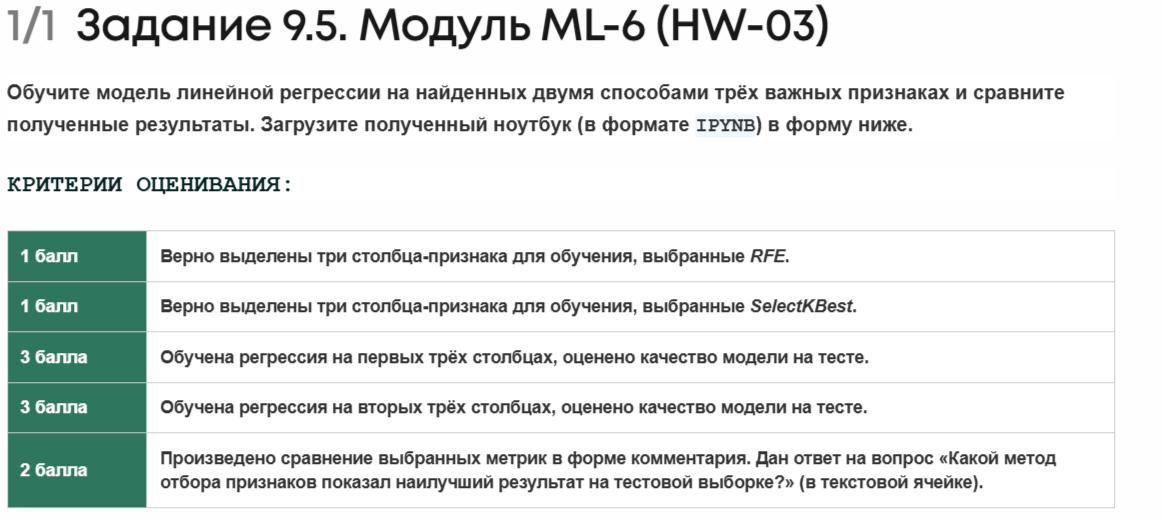

In [119]:
data = pd.read_excel(r'C:\Users\user\Desktop\Skilfactory\data1\data_ford_price.xlsx')

In [120]:
data

,price,year,condition,cylinders,odometer,title_status,transmission,drive,size,lat,long,weather
0,43900,2016,4,6,43500,clean,automatic,4wd,full-size,36.471500,-82.483400,59.0
1,15490,2009,2,8,98131,clean,automatic,4wd,full-size,40.468826,-74.281734,52.0
2,2495,2002,2,8,201803,clean,automatic,4wd,full-size,42.477134,-82.949564,45.0
3,1300,2000,1,8,170305,rebuilt,automatic,4wd,full-size,40.764373,-82.349503,49.0
4,13865,2010,3,8,166062,clean,automatic,4wd,NaN,49.210949,-123.114720,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
7012,22500,2015,3,6,23500,clean,automatic,rwd,full-size,32.680700,-117.169800,59.0
7013,5975,2005,2,8,0,clean,automatic,rwd,full-size,38.213303,-85.785762,50.0
7014,9999,2006,3,8,161514,clean,automatic,NaN,full-size,37.609783,-120.995406,59.0
7015,10900,2011,2,8,164000,clean,automatic,4wd,full-size,43.140600,-93.385000,47.0


In [121]:
data = data[['price','year', 'cylinders', 'odometer', 'lat', 'long', 'weather']]
data = data.dropna()

In [122]:
X, y = data.drop('price', axis=1), data[['price']]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [123]:
lin_reg = LinearRegression()
# модель RFE
rfe = RFE(estimator=lin_reg, n_features_to_select=3)
rfe.fit(X_train, y_train)
print(f'Выбранные признаки: {rfe.get_feature_names_out()}')
print(f'Признаки: {X_train.columns}')
print(f'Ранги признаков: {rfe.ranking_}')

Выбранные признаки: ['year' 'cylinders' 'lat']
Признаки: Index(['year', 'cylinders', 'odometer', 'lat', 'long', 'weather'], dtype='object')
Ранги признаков: [1 1 4 1 3 2]


In [124]:
# Строим модель линейной регрессии на выбранных признах
features_train = X_train[['year', 'cylinders', 'lat']]
features_test = X_test[['year', 'cylinders', 'lat']]
lin_reg_good1 = LinearRegression()
lin_reg_good1.fit(features_train, y_train)
y_test_pred = lin_reg_good1.predict(features_test)

# Выводим результаты
print(f'Метрика MAE на тестовой выборке: {np.round(metrics.mean_absolute_error(y_test, y_test_pred))}')
print(f'Метрика MSE на тестовой выборке: {np.round(metrics.mean_squared_error(y_test, y_test_pred))}')
print(f'Метрика R^2 на тестовой выборке: {np.round(metrics.r2_score(y_test, y_test_pred), 3)}')

Метрика MAE на тестовой выборке: 5164.0
Метрика MSE на тестовой выборке: 49501708.0
Метрика R^2 на тестовой выборке: 0.579


In [125]:
# Отберём 3 признака на основе SelectKBest
Kbest = SelectKBest(f_regression, k=3)
Kbest.fit(X_train, y_train.values.ravel())
print(f'Выбранные признаки: {Kbest.get_feature_names_out()}')

Выбранные признаки: ['year' 'cylinders' 'odometer']


In [126]:
# Строим модель линейной регрессии на выбранных признах
features_train = X_train[['year', 'cylinders', 'odometer']]
features_test = X_test[['year', 'cylinders', 'odometer']]
lin_reg_good2 = LinearRegression()
lin_reg_good2.fit(features_train, y_train)
y_test_pred = lin_reg_good2.predict(features_test)

# Выводим результаты
print(f'Метрика MAE на тестовой выборке: {np.round(metrics.mean_absolute_error(y_test, y_test_pred))}')
print(f'Метрика MSE на тестовой выборке: {np.round(metrics.mean_squared_error(y_test, y_test_pred))}')
print(f'Метрика R^2 на тестовой выборке: {np.round(metrics.r2_score(y_test, y_test_pred), 3)}')

Метрика MAE на тестовой выборке: 4782.0
Метрика MSE на тестовой выборке: 47069835.0
Метрика R^2 на тестовой выборке: 0.6


Результаты моделирования показывают, что алгоритм SelectKBest отбирает параметры лучше, чем RFE.
Все метрики сильно улучшились.

Отдельное моделирование по данным с восстановленными пропусками показало, что качество всех моделей сильно падает. Это может говорить о том, что базовые методы восттановления пропусков с помощью среднего и моды не описывают реальной сущности данных.